<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-6-Improvements_NN/Untitled175.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Elementary Functions Layer**

We consider a collection of elementary functions
$$
\mathcal{S} = \{x,\; e^x,\; \cos x,\; \sin x,\; x^n, \dots\},
$$
where the choice of functions can be adapted to the specific problem. In practice, elements may be added to or removed from this set depending on the expected structure of the solution.


Depending on the complexity of the problem, the EFL can be combined with additional linear layers. For instance, one may introduce a linear layer before the EFL to generate richer input features, or stack multiple EFLs (possibly separated by linear layers) to capture more complex nonlinear compositions of elementary functions.

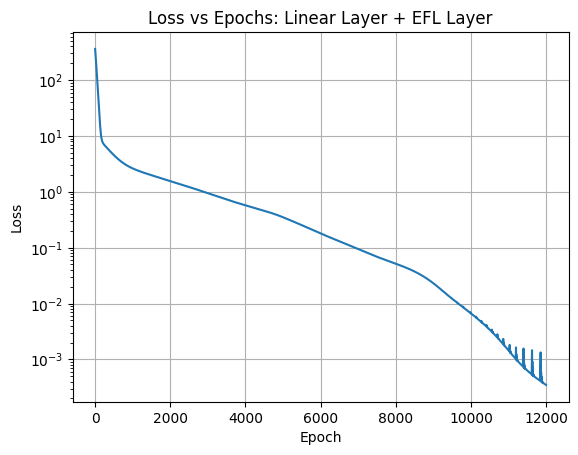

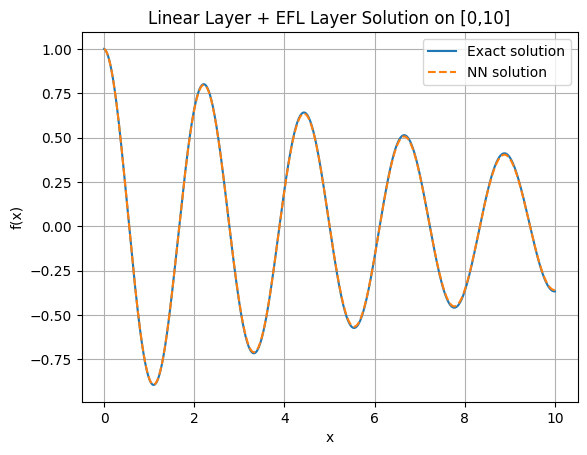

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

tf.random.set_seed(0)
np.random.seed(0)

def f_exact(x):
    return np.exp(-0.1 * x) * np.cos(np.sqrt(31.96) * x / 2.0)

# -------------------------------------------------
# Elementary Functions Layer (EFL)
# Features: {x, cos x, sin x}
# -------------------------------------------------
class EFLLayer(tf.keras.layers.Layer):
    def call(self, x):
        return tf.concat([x, tf.cos(x), tf.sin(x), tf.exp(x/10)], axis=1)

N = 1000
xk = np.linspace(0.0, 10.0, N).reshape(-1, 1).astype(np.float32)
xk_tf = tf.constant(xk)

# Linear layer first, then EFL layer, then FNN
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(5, activation="linear"),
    EFLLayer(),
    tf.keras.layers.Dense(32, activation="tanh"),
    #tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)

mu1 = 100.0
mu2 = 100.0
epochs = 12000
loss_history = []

for ep in range(epochs):
    with tf.GradientTape() as tape:
        with tf.GradientTape() as tape2:
            tape2.watch(xk_tf)
            with tf.GradientTape() as tape1:
                tape1.watch(xk_tf)
                f_val = model(xk_tf)
            f_x = tape1.gradient(f_val, xk_tf)
        f_xx = tape2.gradient(f_x, xk_tf)

        residual = f_xx + 0.2 * f_x + 8.0 * f_val
        loss_ode = tf.reduce_mean(tf.square(residual))

        x0 = tf.constant([[0.0]], dtype=tf.float32)

        with tf.GradientTape() as tape0:
            tape0.watch(x0)
            f0 = model(x0)
        f0_x = tape0.gradient(f0, x0)

        loss_ic = mu1 * tf.square(f0 - 1.0) + mu2 * tf.square(f0_x + 0.1)
        loss = loss_ode + loss_ic[0, 0]

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    loss_history.append(float(loss.numpy()))

# -------------------------------------------------
# Plot loss
# -------------------------------------------------
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs: Linear Layer + EFL Layer")
plt.yscale("log")
plt.grid(True)
plt.show()

# -------------------------------------------------
# Plot NN solution vs exact solution
# -------------------------------------------------
x_plot = np.linspace(0.0, 10.0, 1000).reshape(-1, 1).astype(np.float32)

f_nn = model(tf.constant(x_plot)).numpy().reshape(-1)
f_ex = f_exact(x_plot.reshape(-1))

plt.figure()
plt.plot(x_plot, f_ex, label="Exact solution")
plt.plot(x_plot, f_nn, "--", label="NN solution")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Linear Layer + EFL Layer Solution on [0,10]")
plt.grid(True)
plt.legend()
plt.show()